In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.bin_2d import Tile2Symb2dBin
from image.processing import DITHER_MODES

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 10
MAX_WIDTH = 30
MAX_HEIGHT = 9
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:10]]


def make_converter(params: Params):
    return Tile2Symb2dBin(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: -0.0160 | Max: 0.0684 | Mean: 0.0236 | Std: 0.0245
Min: 0.0406 | Max: 0.1143 | Mean: 0.0832 | Std: 0.0272
Min: 0.0268 | Max: 0.1569 | Mean: 0.0869 | Std: 0.0387
Min: 0.0356 | Max: 0.1777 | Mean: 0.0997 | Std: 0.0399
Min: 0.0241 | Max: 0.1908 | Mean: 0.0908 | Std: 0.0475
Min: 0.0435 | Max: 0.1983 | Mean: 0.0995 | Std: 0.0437
Min: 0.0376 | Max: 0.2064 | Mean: 0.1043 | Std: 0.0454
Min: 0.0377 | Max: 0.2023 | Mean: 0.1044 | Std: 0.0461
Min: 0.0412 | Max: 0.2061 | Mean: 0.1079 | Std: 0.0467


C:\Users\wojte\AppData\Local\Temp\ipykernel_30028\1450432827.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


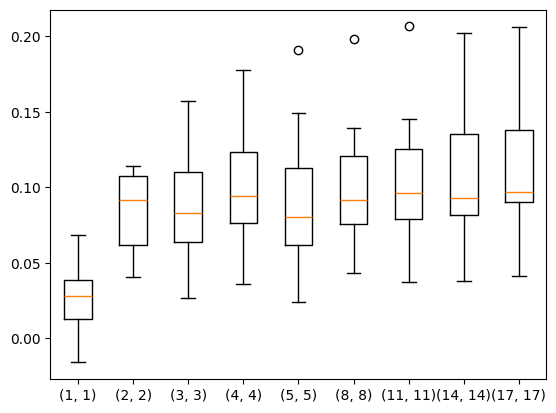

In [3]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'bins': bins},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.FS}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0304 | Max: 0.2094 | Mean: 0.1029 | Std: 0.0454
Min: 0.0352 | Max: 0.1956 | Mean: 0.1022 | Std: 0.0417
Min: 0.0331 | Max: 0.1847 | Mean: 0.0917 | Std: 0.0384
Min: 0.0306 | Max: 0.1793 | Mean: 0.0892 | Std: 0.0388
Min: 0.0350 | Max: 0.1688 | Mean: 0.0830 | Std: 0.0370


C:\Users\wojte\AppData\Local\Temp\ipykernel_30028\2815104393.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


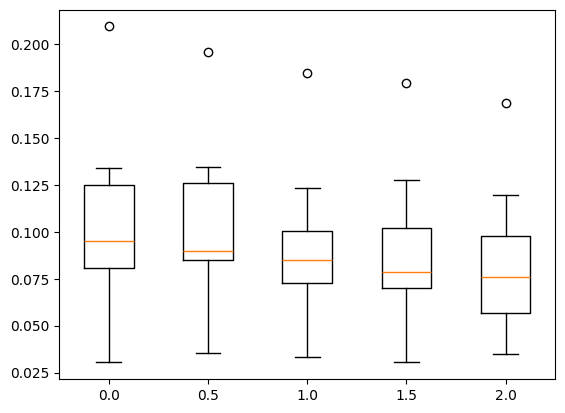

In [ ]:
# edge enhancement

edge_enhancement_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.NONE,
                         'enhance_edges': e}),
        edge_enhancement_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in edge_enhancement_vals])
plt.show()

Min: 0.0770 | Max: 0.3355 | Mean: 0.1952 | Std: 0.0797
Min: 0.0987 | Max: 0.2985 | Mean: 0.1831 | Std: 0.0532
Min: 0.0680 | Max: 0.2612 | Mean: 0.1552 | Std: 0.0509
Min: 0.0406 | Max: 0.2401 | Mean: 0.1417 | Std: 0.0537
Min: 0.0163 | Max: 0.2352 | Mean: 0.1368 | Std: 0.0591


C:\Users\wojte\AppData\Local\Temp\ipykernel_6516\3095627118.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


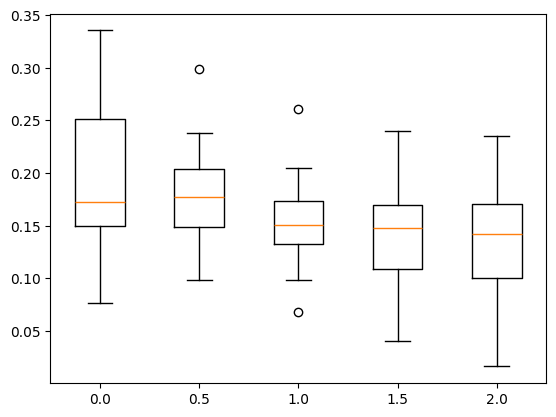

In [2]:
# edge detection

find_edges_vals = [
    e for e in np.linspace(0.0, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda e: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args={'quantize_colors': 2,
                         'dither': DITHER_MODES.NONE,
                         'find_edges': e}),
        find_edges_vals))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[e for e in find_edges_vals])
plt.show()

In [3]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2Symb2dBin(symbols=SYMBOLS,
                           font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS[:5]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img,
                         enhance_edges=0.2,
                         find_edges=1.0,
                         quantize_colors=2, dither=DITHER_MODES.FS)
    win_w = math.ceil(MAX_WIDTH / img.width)
    win_h = win_w * 2
    if MAX_WIDTH:
        scale_w = MAX_WIDTH * win_w / img.width
    if MAX_HEIGHT:
        scale_h = MAX_HEIGHT * win_h / img.height
    img = preprocess_img(img, scale_factor=min(scale_h, scale_w))
    res_arr = converter.process_image(img, (win_w, win_h))
    results.append(res_arr)

print_gallery(results, 2)

---------------------------------------------------------------
 |       `` ````-``  `-   .  - | -\\~/(3(l()/-~~~~-:  --- :_ | 
 |         `       -:: ..   .  | -/_--iJiL()/------- :--`-`- | 
 |                           - | -~-:-(jLti(/_--- --:  --  - | 
 |                           - | --` -)3J(~~~~----    .  - - | 
 | .     -` .-`-:  :-.. .  .:- | `   `\t{((>------.:-------- | 
 | --------------`-~~~~----~-- | -_-  /3ij()<--------------- | 
 | _,______.__---------------_ | \i;,:/JiiC)/---------~~_--~ | 
 | ((r!r\\\==/\_\/\______~~/\\ | /i))>))i))[<--~-//~//_/___/ | 
 | |//~~~\\--~------~----:.--- | iii)ii))ijj1\;<()\__\/(((<| | 
---------------------------------------------------------------
 | `-`-----.----____-------    |              | 
 |         `-------- ``      ` |              | 
 |  :-   . .:  :..-         .- |              | 
 | `---_/\_~\<\\_/\\_-.__//\\\ |     .:::     | 
 | ---/\~/>/\//\///\\/\\~`-_~~ |     \/~\.    | 
 | --____---`~\\/~~///-/---~-  |    :---~-    | 
 |